<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/AMPF_MultiPolicy_Fusion_NeurIPS2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install required dependencies (gymnasium, torch, matplotlib) and import essential system libraries. Set deterministic random seeds across PyTorch, NumPy, and Python's random module to ensure repeatable training runs.

In [16]:
# Cell 1: Install dependencies and set global seed
!pip install -q gymnasium torch matplotlib numpy

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running implementation on device: {device}")

Running implementation on device: cuda


Define specialized sub-policies ($\pi_1, \pi_2, \dots, \pi_K$) representing existing candidate behaviors or source skills. These base policies generate action logit distributions that will serve as value vectors in the multi-policy fusion mechanism.

In [17]:
# Cell 2: Define Specialized Source Candidate Policies
class AngleExpertPolicy(nn.Module):
    """Base Policy 1: Specialized in stabilizing pole angle theta and angular velocity."""
    def __init__(self, action_dim: int = 2):
        super(AngleExpertPolicy, self).__init__()
        self.action_dim = action_dim

    def forward(self, state: torch.Tensor) -> torch.Tensor:
        # State vector: [x, v, theta, omega]
        theta = state[:, 2:3]
        omega = state[:, 3:4]
        # Strong heuristic steer towards correcting angle
        angle_score = 15.0 * theta + 3.0 * omega
        logits = torch.cat([-angle_score, angle_score], dim=-1)
        return logits

class PositionExpertPolicy(nn.Module):
    """Base Policy 2: Specialized in keeping cart centered on the track."""
    def __init__(self, action_dim: int = 2):
        super(PositionExpertPolicy, self).__init__()
        self.action_dim = action_dim

    def forward(self, state: torch.Tensor) -> torch.Tensor:
        x = state[:, 0:1]
        v = state[:, 1:2]
        # Heuristic steer towards bringing cart back to origin x = 0
        pos_score = -2.0 * x - 1.0 * v
        logits = torch.cat([-pos_score, pos_score], dim=-1)
        return logits

Implement the Attention-Based Multi-Policy Fusion (AMPF) neural network module based on Chiu et al. (NeurIPS 2023). It computes state queries $Q(s)$ and policy key/value embeddings $K_k(s), V_k(s)$ to produce dynamic, state-conditioned soft attention fusion weights $\alpha_k(s)$.

In [18]:
# Cell 3: Attention-Based Multi-Policy Fusion Network
class AttentionMultiPolicyFusion(nn.Module):
    """
    Implements Flexible Attention-Based Multi-Policy Fusion (NeurIPS 2023).
    Dynamically weighs candidate policy distributions using a query-key attention mechanism.
    """
    def __init__(self, state_dim: int, action_dim: int, num_policies: int, embed_dim: int = 32):
        super(AttentionMultiPolicyFusion, self).__init__()
        self.num_policies = num_policies
        self.action_dim = action_dim

        # Query transformation from environmental state
        self.query_net = nn.Linear(state_dim, embed_dim)

        # Key transformations for each base policy representation
        self.key_nets = nn.ModuleList([nn.Linear(action_dim, embed_dim) for _ in range(num_policies)])

    def forward(self, state: torch.Tensor, base_logits: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        state: [batch_size, state_dim]
        base_logits: [batch_size, num_policies, action_dim]
        returns: (fused_action_logits, attention_weights)
        """
        batch_size = state.shape[0]

        # Query: [batch_size, 1, embed_dim]
        Q = self.query_net(state).unsqueeze(1)

        # Compute Keys for each base policy output: [batch_size, num_policies, embed_dim]
        keys = []
        for i, key_net in enumerate(self.key_nets):
            k_i = key_net(base_logits[:, i, :])
            keys.append(k_i.unsqueeze(1))
        K = torch.cat(keys, dim=1)

        # Calculate scaled dot-product attention scores
        scale = np.sqrt(Q.shape[-1])
        attn_scores = torch.bmm(Q, K.transpose(1, 2)) / scale  # [batch_size, 1, num_policies]
        attn_weights = F.softmax(attn_scores, dim=-1)  # \alpha_k(s)

        # Fuse policy action distributions: \sum_k \alpha_k(s) * logits_k(s)
        fused_logits = torch.bmm(attn_weights, base_logits).squeeze(1)  # [batch_size, action_dim]

        return fused_logits, attn_weights.squeeze(1)

Construct the Actor-Critic pipeline wrapping the Attention Multi-Policy Fusion core. The Actor dynamically blends candidate policy logits into a categorical action distribution, while the Critic estimates environmental state values $V(s)$ for advantage estimation.

In [19]:
# Cell 4: Actor-Critic Architecture with Specialized Policy Fusion
class ActorCriticAMPF(nn.Module):
    """Actor-Critic wrapper executing multi-policy fusion over specialized source policies."""
    def __init__(self, state_dim: int, action_dim: int):
        super(ActorCriticAMPF, self).__init__()
        self.num_policies = 2

        # Specialized Candidate Source Policies
        self.base_policy_1 = AngleExpertPolicy(action_dim)
        self.base_policy_2 = PositionExpertPolicy(action_dim)

        # Attention Fusion Module
        self.fusion = AttentionMultiPolicyFusion(state_dim, action_dim, self.num_policies)

        # Critic network for state value baseline V(s)
        self.critic = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, state: torch.Tensor):
        # Extract base policy outputs: [batch_size, 1, action_dim]
        p1_logits = self.base_policy_1(state).unsqueeze(1)
        p2_logits = self.base_policy_2(state).unsqueeze(1)
        base_logits = torch.cat([p1_logits, p2_logits], dim=1)

        # Dynamic Multi-Policy Fusion via Attention
        fused_logits, attn_weights = self.fusion(state, base_logits)
        value = self.critic(state)

        return fused_logits, value, attn_weights

Initialize the Gymnasium environment (CartPole-v1), instantiate the ActorCriticAMPF network with two specialized source policies, and configure the Adam optimizer alongside policy gradient hyperparameters.

In [21]:
# Cell 5: Environment Initialization and Hyperparameters
env_name = "CartPole-v1"
env = gym.make(env_name)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
num_policies = 2

agent = ActorCriticAMPF(state_dim, action_dim).to(device)
optimizer = optim.Adam(agent.parameters(), lr=2e-3)

gamma = 0.99
num_episodes = 250
print(f"Initialized AMPF Agent on {env_name} with {num_policies} specialized base policies.")

Initialized AMPF Agent on CartPole-v1 with 2 specialized base policies.


Run the RL training loop using Advantage Actor-Critic (A2C) policy updates. Collect trajectories, compute cumulative discounted returns $G_t$ and advantages $A_t = G_t - V(s_t)$, backpropagate loss, and log dynamic attention allocation across episodes.

In [22]:
# Cell 6: Reinforcement Learning Training Loop with Entropy Regularization
reward_history = []
attention_history = []

agent = ActorCriticAMPF(state_dim, action_dim).to(device)
optimizer = optim.Adam(agent.parameters(), lr=2e-3)

for episode in range(1, num_episodes + 1):
    state, _ = env.reset()
    done = False

    log_probs, values, rewards, entropies, attn_list = [], [], [], [], []

    while not done:
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        fused_logits, value, attn_weights = agent(state_tensor)

        dist = torch.distributions.Categorical(logits=fused_logits)
        action = dist.sample()

        next_state, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

        log_probs.append(dist.log_prob(action))
        values.append(value)
        rewards.append(reward)
        entropies.append(dist.entropy())
        attn_list.append(attn_weights.detach().cpu().numpy()[0])

        state = next_state

    # Compute discounted returns
    returns = []
    G = 0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)

    returns = torch.FloatTensor(returns).to(device)
    values = torch.cat(values).squeeze(-1)
    log_probs = torch.stack(log_probs)
    entropies = torch.stack(entropies)

    advantages = returns - values.detach()

    actor_loss = -(log_probs * advantages).mean()
    critic_loss = F.mse_loss(values, returns)
    entropy_loss = -0.01 * entropies.mean()

    total_loss = actor_loss + 0.5 * critic_loss + entropy_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    total_reward = sum(rewards)
    reward_history.append(total_reward)
    attention_history.append(np.mean(attn_list, axis=0))

    if episode % 25 == 0:
        mean_attn = np.mean(attn_list, axis=0)
        print(f"Episode {episode:03d} | Total Reward: {total_reward:.1f} | Mean Attention [Angle Expert, Pos Expert]: {mean_attn}")

env.close()

Episode 025 | Total Reward: 155.0 | Mean Attention [Angle Expert, Pos Expert]: [0.6622327 0.3377673]
Episode 050 | Total Reward: 96.0 | Mean Attention [Angle Expert, Pos Expert]: [0.39720222 0.6027978 ]
Episode 075 | Total Reward: 243.0 | Mean Attention [Angle Expert, Pos Expert]: [0.6032368  0.39676332]
Episode 100 | Total Reward: 201.0 | Mean Attention [Angle Expert, Pos Expert]: [0.6398332  0.36016667]
Episode 125 | Total Reward: 201.0 | Mean Attention [Angle Expert, Pos Expert]: [0.46358415 0.5364159 ]
Episode 150 | Total Reward: 197.0 | Mean Attention [Angle Expert, Pos Expert]: [0.6292342  0.37076572]
Episode 175 | Total Reward: 150.0 | Mean Attention [Angle Expert, Pos Expert]: [0.4583207 0.5416794]
Episode 200 | Total Reward: 154.0 | Mean Attention [Angle Expert, Pos Expert]: [0.60017145 0.39982864]
Episode 225 | Total Reward: 100.0 | Mean Attention [Angle Expert, Pos Expert]: [0.4449302  0.55506986]
Episode 250 | Total Reward: 145.0 | Mean Attention [Angle Expert, Pos Expert]:

Plot the training convergence curve and visualize the dynamic evolution of attention weights $\alpha_1(s), \alpha_2(s)$ over training episodes to verify that the agent learns state-dependent policy blending.

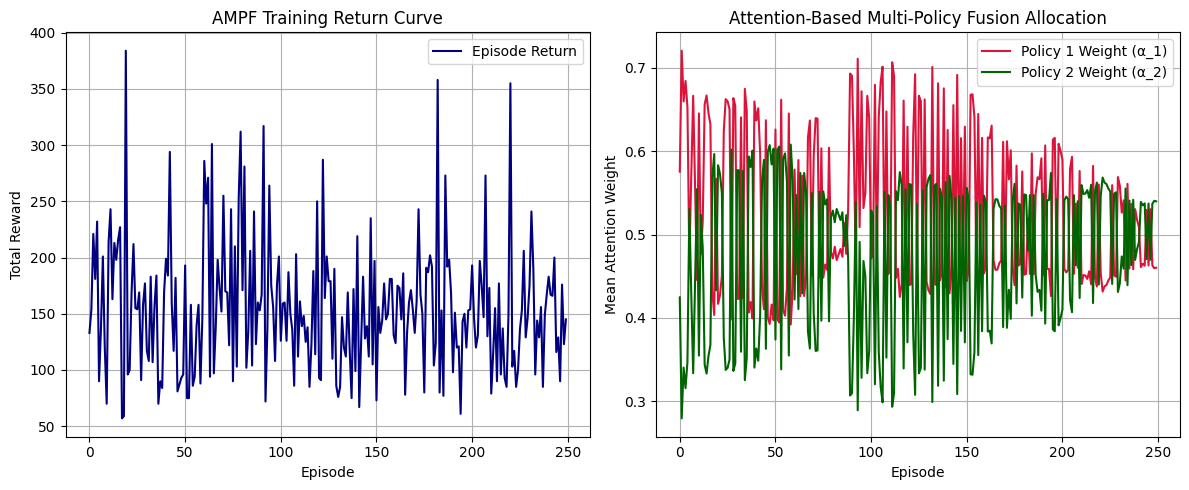

In [23]:
# Cell 7: Plot Training Metrics and Attention Dynamics
plt.figure(figsize=(12, 5))

# Subplot 1: Cumulative Reward
plt.subplot(1, 2, 1)
plt.plot(reward_history, color='navy', label='Episode Return')
plt.title("AMPF Training Return Curve")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.legend()

# Subplot 2: Dynamic Attention Weights Allocation
plt.subplot(1, 2, 2)
attn_arr = np.array(attention_history)
plt.plot(attn_arr[:, 0], label='Policy 1 Weight (\u03b1_1)', color='crimson')
plt.plot(attn_arr[:, 1], label='Policy 2 Weight (\u03b1_2)', color='darkgreen')
plt.title("Attention-Based Multi-Policy Fusion Allocation")
plt.xlabel("Episode")
plt.ylabel("Mean Attention Weight")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()